<a href="https://colab.research.google.com/github/Tookss55/DS/blob/main/Unit8/AmirReganUnit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

Answer2: A decision tree is like a flowchart where each node can only have one parent node but can have as many child nodes as available.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

Answer3: The depth changes how many layers the tree can have, and seems to cause the graph to be more overfit when increasing the depth. If the graph is clearly overfit, you know the depth is too high, and vice versa.

**Task4:**

How are BART models similar and different from a decision tree?

Answer 4: Both BART and a decision tree use the same idea of splitting data into regions and making predictions based on those splits. The difference is that a decision tree uses one large tree, while BART combines many small trees and adds their predictions together.

**Task5**:

Why would we use a BART model instead of a decision tree?

Answer5: BART is more stable, less prone to overfitting, and can estimate uncertainty, while a single decision tree is simpler but less reliable.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

In [ ]:
!pip install pymc-bart

In [4]:
import pymc_bart as pmb

In [13]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguin = pd.read_csv(url).dropna()

In [14]:
clmn_list = ["species", "island", "bill_length", "bill_depth", "flipper_length", "body_mass", "sex", "year"]
peng_stats = penguin.loc[:,clmn_list].dropna()

In [8]:
X = peng_stats[["flipper_length", "bill_depth", "bill_length"]]
Y = peng_stats["body_mass"].to_numpy()

In [ ]:
#from class notes
with pm.Model() as model_pengs:
    s = pm.Normal('s', 10)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Normal("y", mu=μ, sigma=s, observed=Y)
    idata_pengs = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_pengs,model_pengs, extend_inferencedata=True)

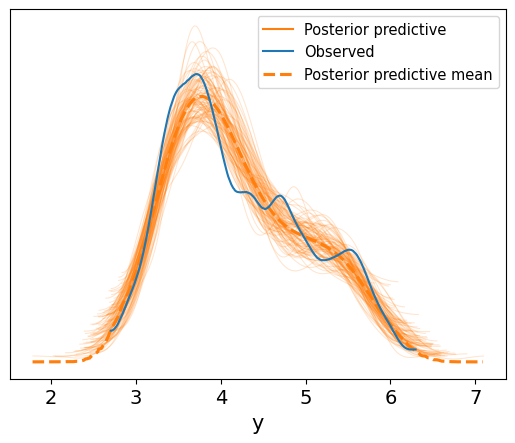

In [18]:
ax = az.plot_ppc(idata_pengs, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

<Axes: xlabel='flipper_length', ylabel='body_mass'>

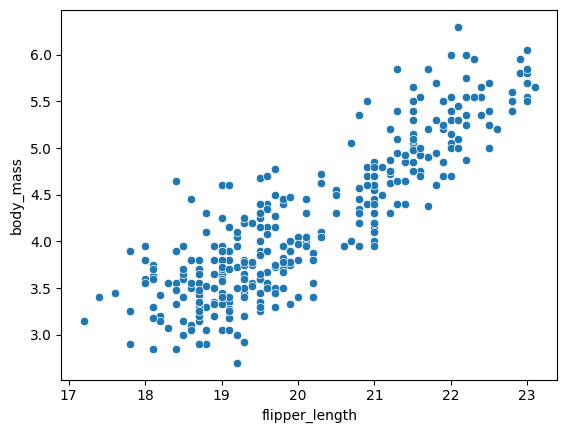

In [19]:
sns.scatterplot(data = peng_stats, y = 'body_mass', x = 'flipper_length')

In [20]:
posterior_mean = idata_pengs.posterior["μ"]

μ_hdi = az.hdi(ary=idata_pengs, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_pengs, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


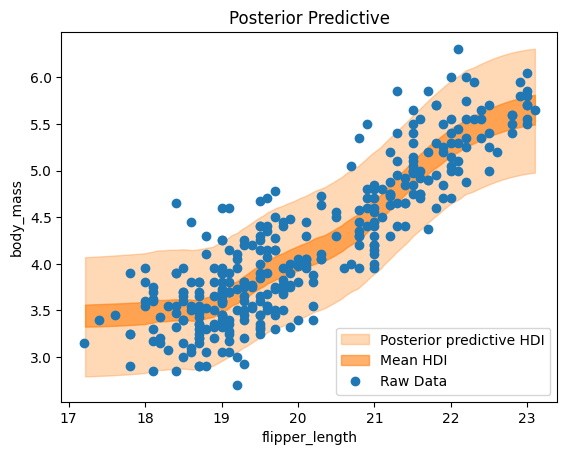

In [22]:
idx = np.argsort(X.to_numpy()[:, 0]) #grabbed from class AK notes
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean HDI"},
)
ax.plot(peng_stats['flipper_length'], peng_stats["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

Answer 8:
Yes, it seems like the model accurately captures the trends from the data between flipper length and body mass. It doesn't overfit the data at all as all of the outliers are ignored.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

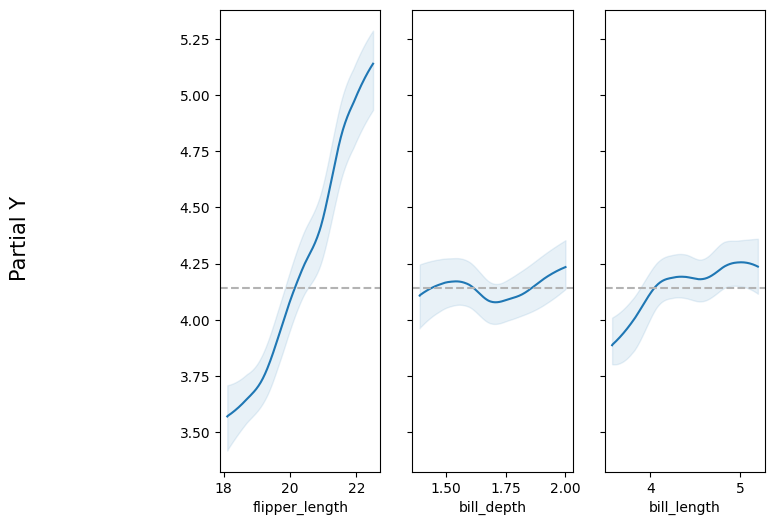

In [29]:
#from notes
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

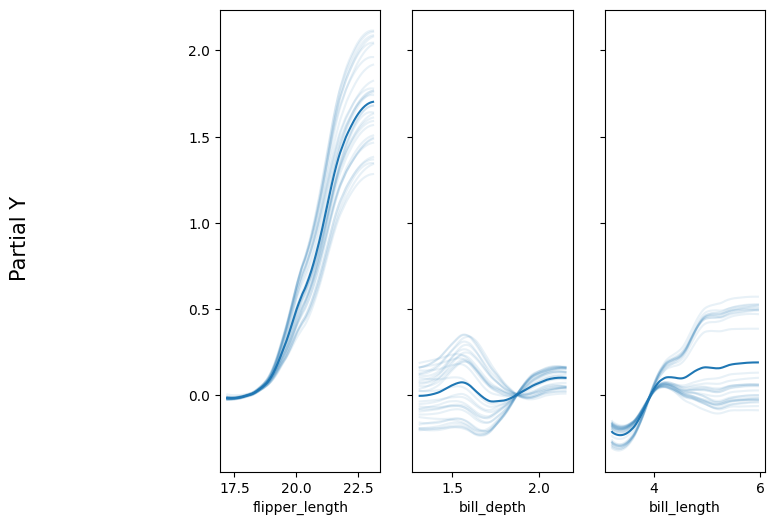

In [30]:
#from notes
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [31]:
#from notes
vi_pengs = pmb.compute_variable_importance(idata_pengs, μ_, X)

<Axes: ylabel='R²'>

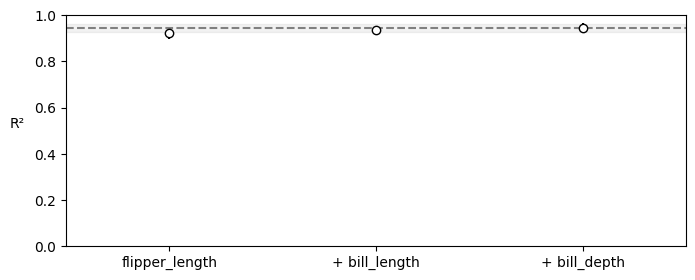

In [32]:
pmb.plot_variable_importance(vi_pengs)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Answer 10:
It looks like flipper length is the main factor in predicting penguin body mass. From the variable plot, adding bill length and bill depth doesn’t really change the R² much, since flipper length alone already gets it close to 0.95. The PDP and ICE plots show that flipper length has a pretty clear, almost linear relationship with body mass, while the other two variables are more inconsistent and don’t show a clear pattern. There also seem to be some interactions at higher values, especially with flipper length and combinations of low bill depth and high bill length, based on how spread out the ICE lines are.